# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [2]:
# Your code here. 
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})

Draw a dispersion diagram (scatter plot) for the data.

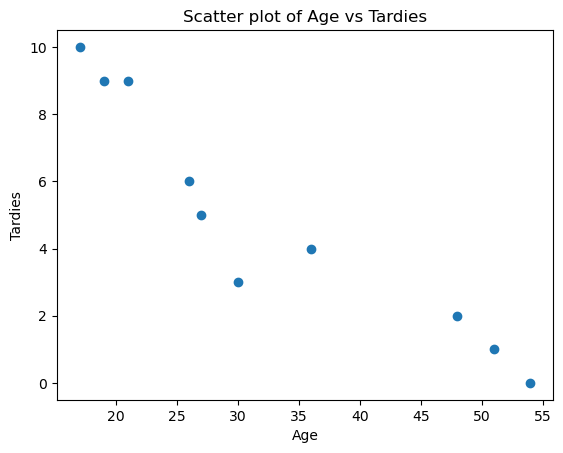

In [3]:
# Your code here
plt.scatter(student_data["Age"], student_data["Tardies"])
plt.xlabel("Age")
plt.ylabel("Tardies")
plt.title("Scatter plot of Age vs Tardies")
plt.show()

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

*your explanation here*
* It seems that there is a descending linear tendency in this data. Meaning that, the older the person, the lower the tardies

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [6]:
# your code here

covariance = np.cov(student_data["Age"], student_data["Tardies"])[0, 1]                 #[o,1] because .cov creates a matrix between Age and Tardies and we indicate the position that relates botch
correlation = np.corrcoef(student_data["Age"], student_data["Tardies"])[0, 1]

print(f"The covariance is {covariance}")
print(f"The correlation is {correlation}")

# Covariance measures how two variables vary together.
# A negative covariance indicates that as Age increases, Tardies tends to decrease.

# Correlation standardizes covariance to a value between -1 and 1.
# The strong negative correlation here indicates a strong inverse linear relationship between Age and Tardies.

The covariance is -45.56666666666666
The correlation is -0.9391626886887122


Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [10]:
# Define variables
X = student_data[["Age"]].values.reshape(-1, 1)      
y = student_data["Tardies"].values    # Outcome (target)

lr = LinearRegression()
lr.fit(X, y)

# Print coefs
print(lr.intercept_, lr.coef_)

# Note: A train-test split is not used here because the dataset is very small

12.888803363135771 [-0.24282077]


In [9]:
# your explanation here

# Outcome variable: Tardies
# Type of regression: Simple Linear Regression
# We use linear regression because we are modeling the linear relationship between one continuous predictor (Age) and one continuous outcome (Tardies).

Plot your regression model on your scatter plot.

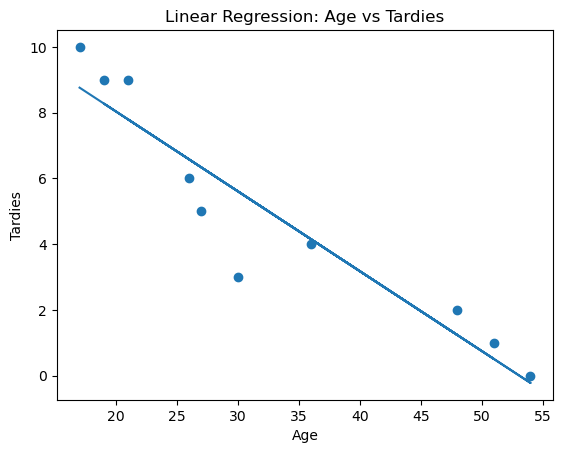

In [15]:
# Your code here.
y_pred = lr.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Age")
plt.ylabel("Tardies")
plt.title("Linear Regression: Age vs Tardies")
plt.show()

Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

*your explanation here*
* Interpretation:

The regression model shows a clear negative linear relationship between Age and Tardies.
Older students are, on average, less likely to be tardy than younger students.

Visually, the regression line fits the data reasonably well, with most points lying close to the line, suggesting a fairly strong linear relationship.

In conclusion, age is a useful predictor of tardiness in this dataset, but more data would be needed to draw strong or definitive conclusions.


## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [16]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("../vehicles.csv")

Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [40]:
# Your code here.
variables = ["Year", "Cylinders", "Fuel Barrels/Year", "Combined MPG", "Fuel Cost/Year"]
target = "CO2 Emission Grams/Mile"

correlations = {}

for var in variables:
    correlations[var] = vehicles[var].corr(vehicles[target])

for var, corr in correlations.items():
    print(f"{var:20s} : {corr: .3f}")


# Fuel Barrels/Year is the strongest predictor of CO₂ emissions, showing an almost perfect positive correlation. 
# Combined MPG also shows a very strong negative relationship, indicating that more fuel-efficient vehicles emit less CO₂. 
# Year provides the least information, showing that newer cards tend to contaminate less, but its correlation is weak.

Year                 : -0.222
Cylinders            :  0.752
Fuel Barrels/Year    :  0.986
Combined MPG         : -0.926
Fuel Cost/Year       :  0.931


Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [32]:
# Your code here.
from sklearn.model_selection import train_test_split

X = vehicles[variables]  #No reshaping because X is a DataFrame with the indicated features(2D shape)
y = vehicles[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

lm = LinearRegression()
lm.fit(X_train, y_train)

coefficients = pd.DataFrame({"Feature": variables,"Coefficient": lm.coef_})
coefficients

# Type of regression: Multiple Linear Regression
# Multiple linear regression is used because we have one continuous outcome and multiple continuous predictors.


,Feature,Coefficient
0,Year,-0.315587
1,Cylinders,1.794026
2,Fuel Barrels/Year,19.231027
3,Combined MPG,-2.933573
4,Fuel Cost/Year,0.031971


Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

In [36]:
# Your code here.
import statsmodels.api as sm

est = sm.OLS(y_train, X_train)
est = est.fit()
est.summary()

# Interpretation:
# Fuel Barrels/Year is the most important predictor, as CO2 emissions are directly linked to fuel consumption. Combined MPG is also highly influential, showing a strong negative relationship with emissions
# Year is the least informative predictor.
# The condition number is large, 2.54e+03. This might indicate that there are strong multicollinearity (various fuel-related variables)
# We are confident in the conclusions because R-squared (99,9%) and Prob (F-statistic):	0.00 make the model strong.

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   OLS Regression Results                                   
============================================================================================
Dep. Variable:     CO2 Emission Grams/Mile   R-squared (uncentered):                   0.999
Model:                                 OLS   Adj. R-squared (uncentered):              0.999
Method:                      Least Squares   F-statistic:                          4.960e+06
Date:                     Thu, 05 Feb 2026   Prob (F-statistic):                        0.00
Time:                             17:39:29   Log-Likelihood:                     -1.2174e+05
No. Observations:                    28761   AIC:                                  2.435e+05
Df Residuals:                        28756   BIC:                                  2.435e+05
Df Model:                                5                                                  
Covariance Type:                 nonrobust                                                  
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Year                  0.0607      0.001     64.823      0.000       0.059       0.063
Cylinders             0.8274      0.090      9.227      0.000       0.652       1.003
Fuel Barrels/Year    20.0363      0.066    305.443      0.000      19.908      20.165
Combined MPG         -2.9317      0.048    -61.407      0.000      -3.025      -2.838
Fuel Cost/Year        0.0289      0.001     53.559      0.000       0.028       0.030
==============================================================================
Omnibus:                    59660.012   Durbin-Watson:                   2.009
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        276321985.860
Skew:                          17.692   Prob(JB):                         0.00
Kurtosis:                     481.883   Cond. No.                     2.54e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.54e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [41]:
# Your code here.
parties= pd.DataFrame({'Invited': [1,3,4,6,8,9,11,14], 'Attend': [1,2,4,4,5,7,8,13]})
parties

,Invited,Attend
0,1,1
1,3,2
2,4,4
3,6,4
4,8,5
5,9,7
6,11,8
7,14,13


Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

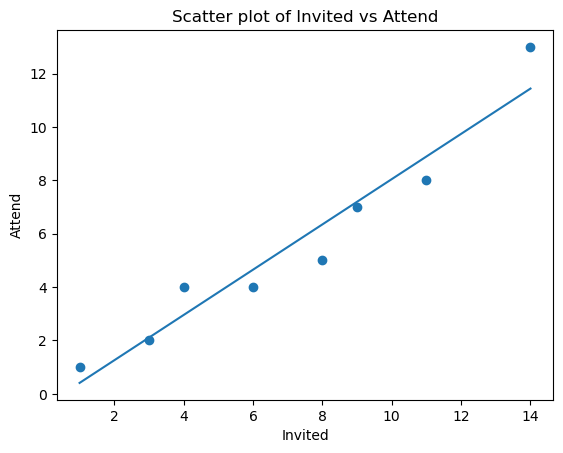

In [43]:
# Your code here.
X = parties[["Invited"]].values.reshape(-1, 1)      
y = parties["Attend"].values    # Outcome (target)

lr = LinearRegression()
lr.fit(X, y)

y_pred = lr.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Invited")
plt.ylabel("Attend")
plt.title("Scatter plot of Invited vs Attend")
plt.show()

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

*your explanation here*
* The regression results suggest that attendance increases at a slower rate than invitations. On average, each additional invitation results in fewer than one additional attendee (0.85), supporting the hypothesis that a larger fraction of invitees are unable to attend as the number of invitations increases

Visually, the regression line fits the data reasonably well, with most points lying close to the line, suggesting a fairly strong linear relationship.

In [44]:
print(lr.intercept_, lr.coef_)

-0.43939393939393945 [0.84848485]


Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

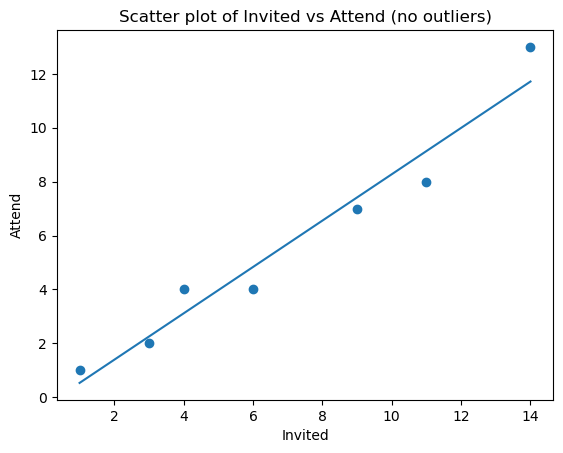

In [49]:
# Your response here.
# The scatter plot does not show any clear outliers or problematic points. However, I will do the calculations removing the most influential point: x=8 y=5

parties_no_out= pd.DataFrame({'Invited2': [1,3,4,6,9,11,14], 'Attend2': [1,2,4,4,7,8,13]})

X = parties_no_out[["Invited2"]].values.reshape(-1, 1)      
y = parties_no_out["Attend2"].values    # Outcome (target)

lr = LinearRegression()
lr.fit(X, y)

y_pred = lr.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Invited")
plt.ylabel("Attend")
plt.title("Scatter plot of Invited vs Attend (no outliers)")
plt.show()

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

*your explanation here*
* The changes were minimal
* After removing the most influential point, the regression slope increases slightly, but the overall conclusion remains the same.
* It is probably due to the small database we are working with